# Exercise 4. Normalization and Standardization 

Deep learning neural networks learn how to map inputs to outputs from examples in a training dataset. The purpose of exercise is to compare results of MLP prediction with raw, normalized and standardized input data.


In [1]:
## Import libraries
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.layers import Dense, Input
from keras.models import Model
from keras.optimizers import SGD
from matplotlib import pyplot
from numpy import mean
from numpy import std
import keras

## Generate regression dataseat
X, y = make_regression(n_samples=1000, n_features=20, noise=0.1, random_state=1)


In [2]:
# Split into training and test dataset, 70/30
# Implementation comes to this cell

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.3,
    random_state = 42
)

print("Train:", X_train.shape, "Test:", X_test.shape)   # (700, 20) and (300, 20)

Train: (700, 20) Test: (300, 20)


In [3]:
# Define MLP using Keras Functional API
# Input layer with suitable amount of nodes
# Hidden layer with 25 nodes: activation='relu', kernel_initializer='he_uniform'
# Output layer 1 node (prediction), activation = 'linear'
# Implementation comes to this cell

inputs = Input(shape=(X_train.shape[1],))
hidden = Dense(25, activation='relu', kernel_initializer='he_uniform')(inputs)
outputs = Dense(1, activation='linear')(hidden)
model = Model(inputs=inputs, outputs=outputs)

# Compile model with following options: 
# The mean squared error loss function will be used to optimize the model and 
# the stochastic gradient descent optimization algorithm

model.compile(loss='mean_squared_error', optimizer=SGD(learning_rate=0.01, momentum=0.9))

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │           525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551 (2.15 KB)

 Trainable params: 551 (2.15 KB)

 Non-trainable params: 0 (0.00 B)

## Raw data as input

Repeat each 5 times and save the results

In [21]:
# Fit model: epoch = 100

raw_histories = []   # loss history of each run (for plotting)
raw_train_mse = []   # train MSE of each run
raw_test_mse = []    # test MSE of each run

for run in range(5):
    keras.utils.set_random_seed(run)   # seeds 0-4; use the same in every section

    # Build a fresh model for each run
    inputs = Input(shape=(X_train.shape[1],))
    x = Dense(25, activation='relu', kernel_initializer='he_uniform')(inputs)
    outputs = Dense(1, activation='linear')(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(loss='mean_squared_error', optimizer=SGD(learning_rate=0.001, momentum=0.9))

    # Train on raw data
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, verbose=0)

    # Save the results of this run
    raw_histories.append(history)
    raw_train_mse.append(model.evaluate(X_train, y_train, verbose=0))
    raw_test_mse.append(model.evaluate(X_test, y_test, verbose=0))

In [22]:
# Evaluate model: mse 
# Implementation comes to this cell
for run in range(5):
    print(f"Run {run + 1}: Train MSE = {raw_train_mse[run]:.3f}, Test MSE = {raw_test_mse[run]:.3f}")

print(f"\nRaw data → Mean test MSE: {mean(raw_test_mse):.3f} (± {std(raw_test_mse):.3f})")

Run 1: Train MSE = 0.186, Test MSE = 0.178
Run 2: Train MSE = 0.201, Test MSE = 0.357
Run 3: Train MSE = 1.160, Test MSE = 2.391
Run 4: Train MSE = 0.019, Test MSE = 0.294
Run 5: Train MSE = 0.208, Test MSE = 0.843

Raw data → Mean test MSE: 0.813 (± 0.821)


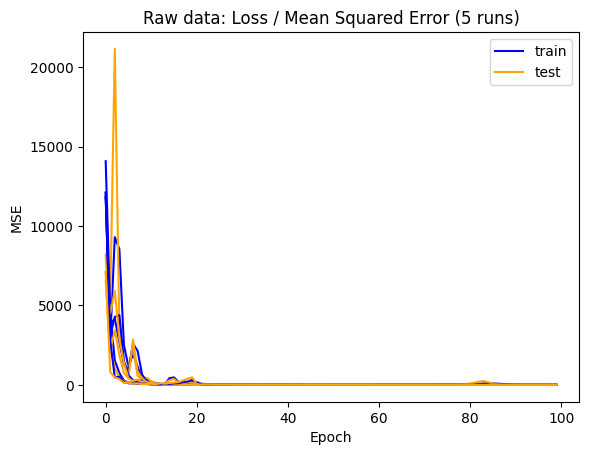

In [23]:
# Plot loss during training
# Implementation comes to this cell

for run in range(5):
    pyplot.plot(raw_histories[run].history['loss'], color='blue', label='train' if run == 0 else None)
    pyplot.plot(raw_histories[run].history['val_loss'], color='orange', label='test' if run == 0 else None)

pyplot.title('Raw data: Loss / Mean Squared Error (5 runs)')
pyplot.xlabel('Epoch')
pyplot.ylabel('MSE')
pyplot.legend()
pyplot.show()


## Normalized data (MinMaxScaler)
Repeat each 5 times and save the results

In [24]:
# Normalize data
# Implementation comes to this cell

# Normalize inputs (X): fit on training data only
x_scaler_norm = MinMaxScaler()
X_train_norm = x_scaler_norm.fit_transform(X_train)
X_test_norm = x_scaler_norm.transform(X_test)

# Normalize output (y): needed for Version 2 only
y_scaler_norm = MinMaxScaler()
y_train_norm = y_scaler_norm.fit_transform(y_train.reshape(-1, 1))
y_test_norm = y_scaler_norm.transform(y_test.reshape(-1, 1))

In [25]:
# Version 1: only X normalized, y raw

# Fit model: epoch = 100
# Implementation comes to this cell

normx_histories = []   # loss history of each run (for plotting)
normx_train_mse = []   # train MSE of each run
normx_test_mse = []    # test MSE of each run

for run in range(5):
    keras.utils.set_random_seed(run)

    # Build a fresh model for each run
    inputs = Input(shape=(X_train_norm.shape[1],))
    x = Dense(25, activation='relu', kernel_initializer='he_uniform')(inputs)
    outputs = Dense(1, activation='linear')(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(loss='mean_squared_error', optimizer=SGD(learning_rate=0.001, momentum=0.9))

    # Train with normalized X and raw y
    history = model.fit(X_train_norm, y_train, validation_data=(X_test_norm, y_test),
                        epochs=100, verbose=0)

    # Save the results of this run
    normx_histories.append(history)
    normx_train_mse.append(model.evaluate(X_train_norm, y_train, verbose=0))
    normx_test_mse.append(model.evaluate(X_test_norm, y_test, verbose=0))

In [9]:
# Version 1: only X normalized, y raw

# Evaluate model: mse 
# Implementation comes to this cell

for run in range(5):
    print(f"Run {run + 1}: Train MSE = {normx_train_mse[run]:.3f}, Test MSE = {normx_test_mse[run]:.3f}")

print(f"\nOnly X normalized → Mean test MSE: {mean(normx_test_mse):.3f} (± {std(normx_test_mse):.3f})")

Run 1: Train MSE = 22123.127, Test MSE = 26113.688
Run 2: Train MSE = 22118.721, Test MSE = 26095.955
Run 3: Train MSE = 22127.125, Test MSE = 26122.510
Run 4: Train MSE = 22118.875, Test MSE = 26099.230
Run 5: Train MSE = 22122.111, Test MSE = 26088.883

Only X normalized → Mean test MSE: 26104.053 (± 12.267)


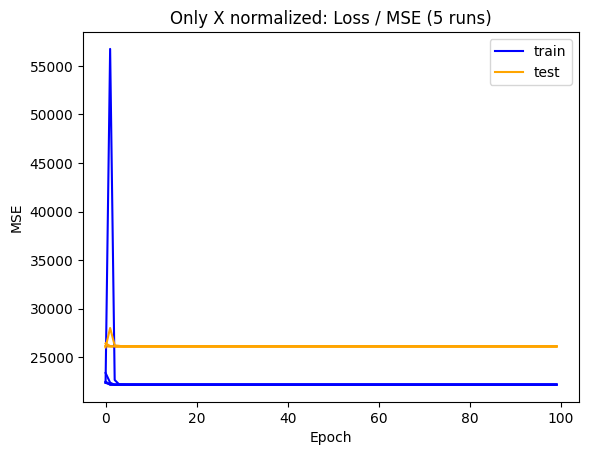

In [10]:
# Version 1: only X normalized, y raw

# Plot loss during training
# Implementation comes to this cell

for run in range(5):
    pyplot.plot(normx_histories[run].history['loss'], color='blue', label='train' if run == 0 else None)
    pyplot.plot(normx_histories[run].history['val_loss'], color='orange', label='test' if run == 0 else None)

pyplot.title('Only X normalized: Loss / MSE (5 runs)')
pyplot.xlabel('Epoch')
pyplot.ylabel('MSE')
pyplot.legend()
pyplot.show()

In [ ]:
# Version 2: X and y normalized

# Fit model: epoch = 100
# Implementation comes to this cell

normxy_histories = []   # loss history of each run (for plotting)
normxy_train_mse = []   # train MSE of each run
normxy_test_mse = []    # test MSE of each run

for run in range(5):
    keras.utils.set_random_seed(run)

    # Build a fresh model for each run
    inputs = Input(shape=(X_train_norm.shape[1],))
    x = Dense(25, activation='relu', kernel_initializer='he_uniform')(inputs)
    outputs = Dense(1, activation='linear')(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(loss='mean_squared_error', optimizer=SGD(learning_rate=0.001, momentum=0.9))

    # Train with normalized X and normalized y
    history = model.fit(X_train_norm, y_train_norm, validation_data=(X_test_norm, y_test_norm),
                        epochs=100, verbose=0)

    # Save the results of this run
    normxy_histories.append(history)
    normxy_train_mse.append(model.evaluate(X_train_norm, y_train_norm, verbose=0))
    normxy_test_mse.append(model.evaluate(X_test_norm, y_test_norm, verbose=0))

In [12]:
# Version 2: X and y normalized

# Evaluate model: mse
# Implementation comes to this cell

for run in range(5):
    print(f"Run {run + 1}: Train MSE = {normxy_train_mse[run]:.6f}, Test MSE = {normxy_test_mse[run]:.6f}")

print(f"\nX and y normalized → Mean test MSE: {mean(normxy_test_mse):.6f} (± {std(normxy_test_mse):.6f})")

Run 1: Train MSE = 0.000346, Test MSE = 0.000378
Run 2: Train MSE = 0.000105, Test MSE = 0.000132
Run 3: Train MSE = 0.000140, Test MSE = 0.000154
Run 4: Train MSE = 0.000189, Test MSE = 0.000225
Run 5: Train MSE = 0.000112, Test MSE = 0.000213

X and y normalized → Mean test MSE: 0.000221 (± 0.000086)


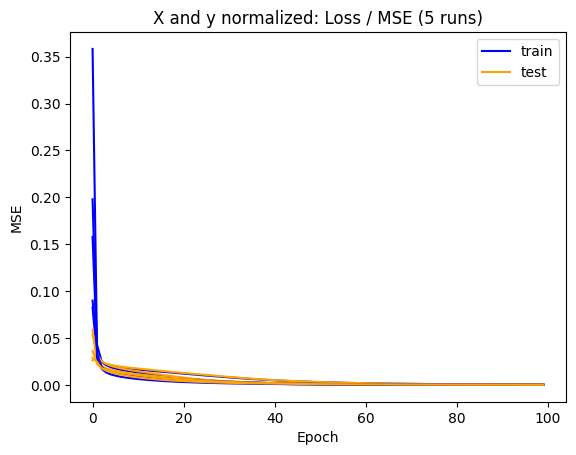

In [13]:
# Version 2: X and y normalized

# Plot loss during training
# Implementation comes to this cell

for run in range(5):
    pyplot.plot(normxy_histories[run].history['loss'], color='blue', label='train' if run == 0 else None)
    pyplot.plot(normxy_histories[run].history['val_loss'], color='orange', label='test' if run == 0 else None)

pyplot.title('X and y normalized: Loss / MSE (5 runs)')
pyplot.xlabel('Epoch')
pyplot.ylabel('MSE')
pyplot.legend()
pyplot.show()

## Standardized data
Repeat each 5 times and save the results

In [14]:
# Standardize data
# Implementation comes to this cell

# Standardize inputs (X): fit on training data only
x_scaler_std = StandardScaler()
X_train_std = x_scaler_std.fit_transform(X_train)
X_test_std = x_scaler_std.transform(X_test)

# Standardize output (y): needed for Version 2 only
y_scaler_std = StandardScaler()
y_train_std = y_scaler_std.fit_transform(y_train.reshape(-1, 1))
y_test_std = y_scaler_std.transform(y_test.reshape(-1, 1))

In [ ]:
# Version 1: only X standardized, y raw

# Fit model: epochs = 100
# Implementation comes to this cell

stdx_histories = []   # loss history of each run (for plotting)
stdx_train_mse = []   # train MSE of each run
stdx_test_mse = []    # test MSE of each run

for run in range(5):
    keras.utils.set_random_seed(run)

    # Build a fresh model for each run
    inputs = Input(shape=(X_train_std.shape[1],))
    x = Dense(25, activation='relu', kernel_initializer='he_uniform')(inputs)
    outputs = Dense(1, activation='linear')(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(loss='mean_squared_error', optimizer=SGD(learning_rate=0.001, momentum=0.9))

    # Train with standardized X and raw y
    history = model.fit(X_train_std, y_train, validation_data=(X_test_std, y_test),
                        epochs=100, verbose=0)

    # Save the results of this run
    stdx_histories.append(history)
    stdx_train_mse.append(model.evaluate(X_train_std, y_train, verbose=0))
    stdx_test_mse.append(model.evaluate(X_test_std, y_test, verbose=0))

In [16]:
# Version 1: only X standardized, y raw

# Evaluate model: mse 
# Implementation comes to this cell

for run in range(5):
    print(f"Run {run + 1}: Train MSE = {stdx_train_mse[run]:.3f}, Test MSE = {stdx_test_mse[run]:.3f}")

print(f"\nOnly X standardized → Mean test MSE: {mean(stdx_test_mse):.3f} (± {std(stdx_test_mse):.3f})")

Run 1: Train MSE = nan, Test MSE = nan
Run 2: Train MSE = nan, Test MSE = nan
Run 3: Train MSE = nan, Test MSE = nan
Run 4: Train MSE = nan, Test MSE = nan
Run 5: Train MSE = nan, Test MSE = nan

Only X standardized → Mean test MSE: nan (± nan)


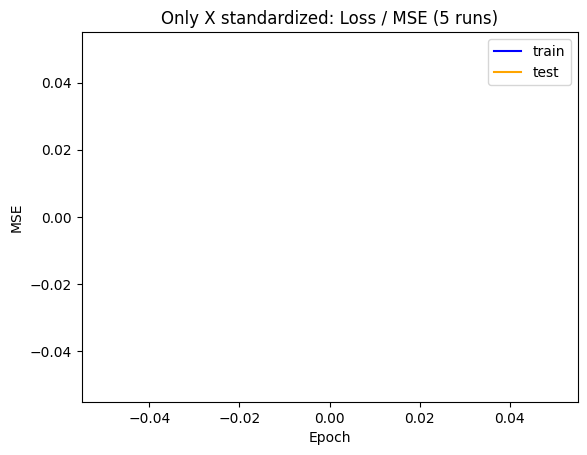

In [17]:
# Version 1: only X standardized, y raw

# Plot loss during training
# Implementation comes to this cell

for run in range(5):
    pyplot.plot(stdx_histories[run].history['loss'], color='blue', label='train' if run == 0 else None)
    pyplot.plot(stdx_histories[run].history['val_loss'], color='orange', label='test' if run == 0 else None)

pyplot.title('Only X standardized: Loss / MSE (5 runs)')
pyplot.xlabel('Epoch')
pyplot.ylabel('MSE')
pyplot.legend()
pyplot.show()

In [ ]:
# Version 2: X and y standardized

# Fit model: epoch = 100
# Implementation comes to this cell

stdxy_histories = []      # loss history of each run (for plotting)
stdxy_train_mse = []      # train MSE of each run (standardized units)
stdxy_test_mse = []       # test MSE of each run (standardized units)
stdxy_test_mse_orig = []  # test MSE of each run (original y units)

for run in range(5):
    keras.utils.set_random_seed(run)

    # Build a fresh model for each run
    inputs = Input(shape=(X_train_std.shape[1],))
    x = Dense(25, activation='relu', kernel_initializer='he_uniform')(inputs)
    outputs = Dense(1, activation='linear')(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(loss='mean_squared_error', optimizer=SGD(learning_rate=0.001, momentum=0.9))

    # Train with standardized X and standardized y
    history = model.fit(X_train_std, y_train_std, validation_data=(X_test_std, y_test_std),
                        epochs=100, verbose=0)

    # Save the results of this run
    stdxy_histories.append(history)
    stdxy_train_mse.append(model.evaluate(X_train_std, y_train_std, verbose=0))
    stdxy_test_mse.append(model.evaluate(X_test_std, y_test_std, verbose=0))

    # Convert predictions back to original units and compute MSE there
    pred = y_scaler_std.inverse_transform(model.predict(X_test_std, verbose=0)).ravel()
    stdxy_test_mse_orig.append(mean((pred - y_test) ** 2))

In [19]:
# Version 2: X and y standardized

# Evaluate model: mse
# Implementation comes to this cell

for run in range(5):
    print(f"Run {run + 1}: Train MSE = {stdxy_train_mse[run]:.6f}, Test MSE = {stdxy_test_mse[run]:.6f}, "
          f"Test MSE (original units) = {stdxy_test_mse_orig[run]:.3f}")

print(f"\nX and y standardized → Mean test MSE: {mean(stdxy_test_mse):.6f} (± {std(stdxy_test_mse):.6f})")
print(f"X and y standardized → Mean test MSE (original units): "
      f"{mean(stdxy_test_mse_orig):.3f} (± {std(stdxy_test_mse_orig):.3f})")

Run 1: Train MSE = 0.000054, Test MSE = 0.000091, Test MSE (original units) = 2.015
Run 2: Train MSE = 0.001248, Test MSE = 0.002257, Test MSE (original units) = 49.914
Run 3: Train MSE = 0.001852, Test MSE = 0.004891, Test MSE (original units) = 108.188
Run 4: Train MSE = 0.000712, Test MSE = 0.001447, Test MSE (original units) = 32.005
Run 5: Train MSE = 0.001080, Test MSE = 0.002362, Test MSE (original units) = 52.252

X and y standardized → Mean test MSE: 0.002210 (± 0.001568)
X and y standardized → Mean test MSE (original units): 48.875 (± 34.673)


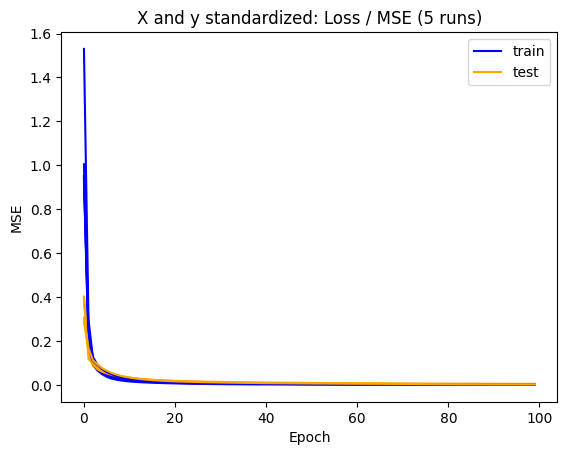

In [20]:
# Version 2: X and y standardized

# Plot loss during training
# Implementation comes to this cell

for run in range(5):
    pyplot.plot(stdxy_histories[run].history['loss'], color='blue', label='train' if run == 0 else None)
    pyplot.plot(stdxy_histories[run].history['val_loss'], color='orange', label='test' if run == 0 else None)

pyplot.title('X and y standardized: Loss / MSE (5 runs)')
pyplot.xlabel('Epoch')
pyplot.ylabel('MSE')
pyplot.legend()
pyplot.show()

__Conclusion__

__NOTE: Conclusion is one evaluation criterion for the exercise, so pay attention to writing them__

Write conclusion:
- Differences between raw, normalized and standardized data?
- What you learn in this exercise?
- Did you have difficulties in the exercise?
- Etc.

